# Relatório Final
**Título:** Triagem Preditiva de Fármacos Antiepilépticos

**Disciplina:** Introdução à Ciência de Dados - UFPB  

**Professor:** Dr. Yuri Malheiros  

**Integrantes da Equipe:**
* Álefe Brito Monteiro
* Antonio Jose Batista Salazar
* Igor Barbosa Rodrigues de Oliveira
* João Batista de Araújo Martins

## 1. Introdução

### Motivação
A descoberta de novos fármacos antiepilépticos é um processo historicamente longo, altamente custoso e que demanda um grande volume de testes exploratórios experimentais *in vivo* (em animais). Otimizar e modernizar a etapa de triagem dessas novas moléculas através de modelos computacionais e Ciência de Dados tem um impacto imenso não apenas financeiro, mas ético. Ao utilizar a Inteligência Artificial como um filtro preditivo inicial, o projeto alinha-se aos princípios bioéticos dos **3Rs (*Replacement, Reduction, Refinement* - Substituição, Redução e Refinamento)**, diminuindo drasticamente o sacrifício de animais em laboratório.

### Objetivos da Análise
O objetivo principal deste relatório é construir e analisar uma *baseline* (matriz de dados) oriunda da mineração de textos da literatura científica global, focada exclusivamente em artigos que utilizaram o modelo agudo de crises epilépticas induzidas por Pentilenotetrazol (PTZ) em camundongos. 

Através da Análise Exploratória dos Dados (EDA) e do uso de algoritmos de Agrupamento (*Clustering*), buscaremos responder a perguntas de pesquisa fundamentais para:
1. Compreender a distribuição, as vias de administração e as dosagens testadas na literatura.
2. Mapear a correlação entre diferentes desfechos clínicos (proteção contra a crise, severidade e sobrevivência).
3. Agrupar compostos por similaridade de comportamento farmacológico, prevendo a eficácia de novas entidades químicas de forma binária (1 = protege, 0 = inativo).

In [65]:
!pip install matplotlib seaborn openpyxl

In [66]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_excel('dataset_baseline_ptz (dados limpos).xlsx')

print(f"O dataset possui {df.shape[0]} instâncias (linhas) e {df.shape[1]} atributos (colunas).\n")

display(df.head())

O dataset possui 105 instâncias (linhas) e 8 atributos (colunas).



,pmid_referencia,substancia_testada,dose_mg_kg,via_administration,aumento_latencia_crise,reducao_severidade_racine,protecao_contra_morte,target_anticonvulsivante
0,PMID42192296,Sulfasalazine,100.0,i.p.,0.0,1.0,0.0,1
1,PMC12477776,Emodin,200.0,i.p.,0.0,1.0,0.0,1
2,PMID40437665,Stevioside,100.0,i.p.,0.0,0.0,0.0,0
3,PMC12062037,"(1,8-bis(phenylsulfonyl)-1,8-dihydropyrrolo [2...",5.0,p.o.,0.0,0.0,0.0,0
4,PMID39869286,Dapsone,20.0,i.p.,1.0,0.0,0.0,1


## 2. Dados Usados e Exploração Inicial

A base de dados utilizada neste projeto é fruto de um pipeline de mineração de textos científicos (*Web Scraping* e NLP) aplicado aos resumos (*abstracts*) da base de dados internacional do PubMed. O *dataset* captura resultados de ensaios farmacológicos *in vivo* que avaliaram entidades químicas inéditas no modelo de convulsão induzida por Pentilenotetrazol (PTZ) em camundongos.

A exploração inicial realizada na célula acima demonstra que o nosso conjunto possui instâncias bem definidas, apresentando as features metodológicas (composto, dose e via de administração) alinhadas aos fenótipos de resposta (latência, severidade e mortalidade).

## 3. Pré-processamento e Decisões Tomadas

Durante a fase de coleta e preparação, tomamos duas decisões fundamentais de pré-processamento:

1. **Transformação de Contínuo para Binário (Evitando Esparsidade):** Devido à extrema despadronização dos relatos estatísticos na literatura (alguns autores utilizam médias e desvios, outros medianas e intervalos), a extração de dados contínuos exatos geraria um *DataFrame* com altíssima ausência de dados (`NaN`). A decisão arquitetural adotada foi pivotar o problema de Regressão para um problema mais robusto de Classificação. Os tempos exatos foram convertidos em **Fenótipos Binários** (1 para eficácia estatisticamente validada por *p < 0.05*, 0 para ausência de efeito).

2. **Curadoria Manual e Recuperação de Dados (*Sweat Equity*):** Como os algoritmos de extração de texto geram ruídos inevitáveis (*artifacts*), a equipe aplicou o princípio do esforço humano na validação da planilha exportada (`.xlsx`), atuando em três frentes de limpeza:
    *   **Higienização Semântica:** A coluna `substancia_testada` passou por revisão rigorosa para a remoção de termos indesejados ("lixo"), isolando perfeitamente a entidade química investigada.
    *   **Imputação na Via de Administração:** Instâncias que apresentaram valores ausentes na coluna `via_administracao` durante a extração automática tiveram seus artigos originais consultados individualmente pela equipe, permitindo o preenchimento correto desta feature.
    *   **Auditoria das Variáveis Alvo:** A classificação binária (1 e 0) dos fenótipos de eficácia e proteção foi revisada linha a linha para corrigir inconsistências de interpretação do robô.

# 4. Análise Exploratória e Perguntas de Pesquisa

### Pergunta 1: Qual a via de administração mais testada na literatura e qual apresenta a maior taxa de sucesso preditivo?

**Justificativa:** A biodisponibilidade de um fármaco depende fortemente de como ele é introduzido no organismo. Nosso objetivo aqui é mapear se a literatura foca mais em rotas sistêmicas rápidas (como a via intraperitoneal - i.p.) ou vias de uso clínico crônico (como a oral - p.o.), e avaliar se alguma dessas vias possui historicamente uma probabilidade maior de resultar em eficácia anticonvulsivante (Target = 1). 
Para isso, utilizamos **Gráficos de Barras**, ideais para a comparação precisa de variáveis categóricas.

C:\Users\Windows\AppData\Local\Temp\ipykernel_10476\1445274819.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='via_administration', palette='viridis',
C:\Users\Windows\AppData\Local\Temp\ipykernel_10476\1445274819.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='via_administration', y='target_anticonvulsivante',


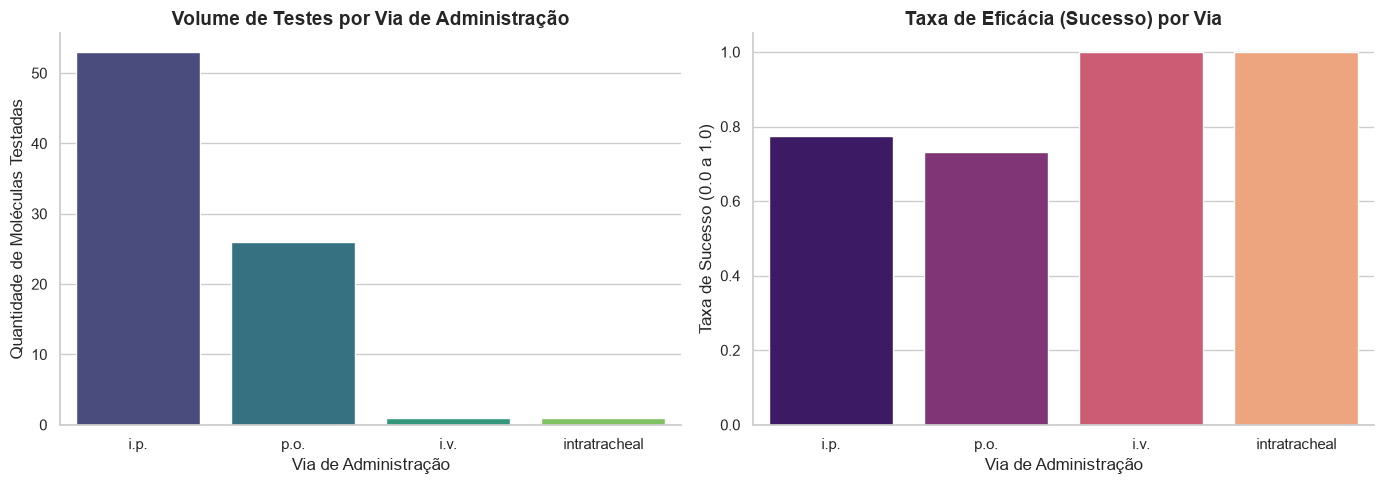

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ordem_vias = df['via_administration'].value_counts().index

sns.countplot(data=df, x='via_administration', palette='viridis', 
              order=ordem_vias, ax=axes[0])

axes[0].set_title('Volume de Testes por Via de Administração', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Via de Administração', fontsize=12)
axes[0].set_ylabel('Quantidade de Moléculas Testadas', fontsize=12)

sns.barplot(data=df, x='via_administration', y='target_anticonvulsivante', 
            palette='magma', order=ordem_vias, ax=axes[1], errorbar=None)
axes[1].set_title('Taxa de Eficácia (Sucesso) por Via', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Via de Administração', fontsize=12)
axes[1].set_ylabel('Taxa de Sucesso (0.0 a 1.0)', fontsize=12)

sns.despine()

plt.tight_layout()
plt.show()

**Conclusão da Pergunta 1:**
Ao analisar os gráficos de barras, observamos que a via de administração **intraperitoneal (i.p.)** é a mais utilizada nos testes pré-clínicos exploratórios com o modelo PTZ, refletindo a preferência da literatura por rotas de rápida absorção sistêmica, seguida pela via oral (p.o.). 

No entanto, ao avaliarmos a eficácia terapêutica predita (Target), notamos um fenômeno estatístico clássico no gráfico de barras à direita: as vias *i.v.* e *intratracheal* apresentam 100% de sucesso (1.0), porém isso é um **artefato causado pelo baixíssimo tamanho amostral** dessas classes. Analisando criticamente apenas as vias com volume amostral robusto, a via **intraperitoneal (i.p.)** se confirma como a mais promissora, apresentando a maior taxa de sucesso proporcional e convertendo quase **80%** das moléculas testadas em proteção efetiva contra as crises epilépticas, enquanto a via oral apresenta uma taxa de sucesso próxima aos 70%.

### Pergunta 2: Como as doses (mg/kg) testadas estão distribuídas entre as moléculas que foram eficazes (Target = 1) e as que falharam (Target = 0)?

**Justificativa:** Na farmacologia, a eficácia de um composto está intimamente ligada à sua dose. Nós queremos investigar se os compostos que falharam na literatura (Target = 0) foram testados, em média, em dosagens menores ou maiores do que aqueles que obtiveram sucesso (Target = 1).
Para responder a esta pergunta, utilizamos o **Boxplot (Diagrama de Caixa)**, que nos permitiu comparar as medianas, o intervalo interquartil (IIQ) e identificar possíveis *outliers* (valores extremos) nas dosagens administradas em ambos os desfechos.

C:\Users\Windows\AppData\Local\Temp\ipykernel_10476\2006374717.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='target_anticonvulsivante', y='dose_mg_kg',


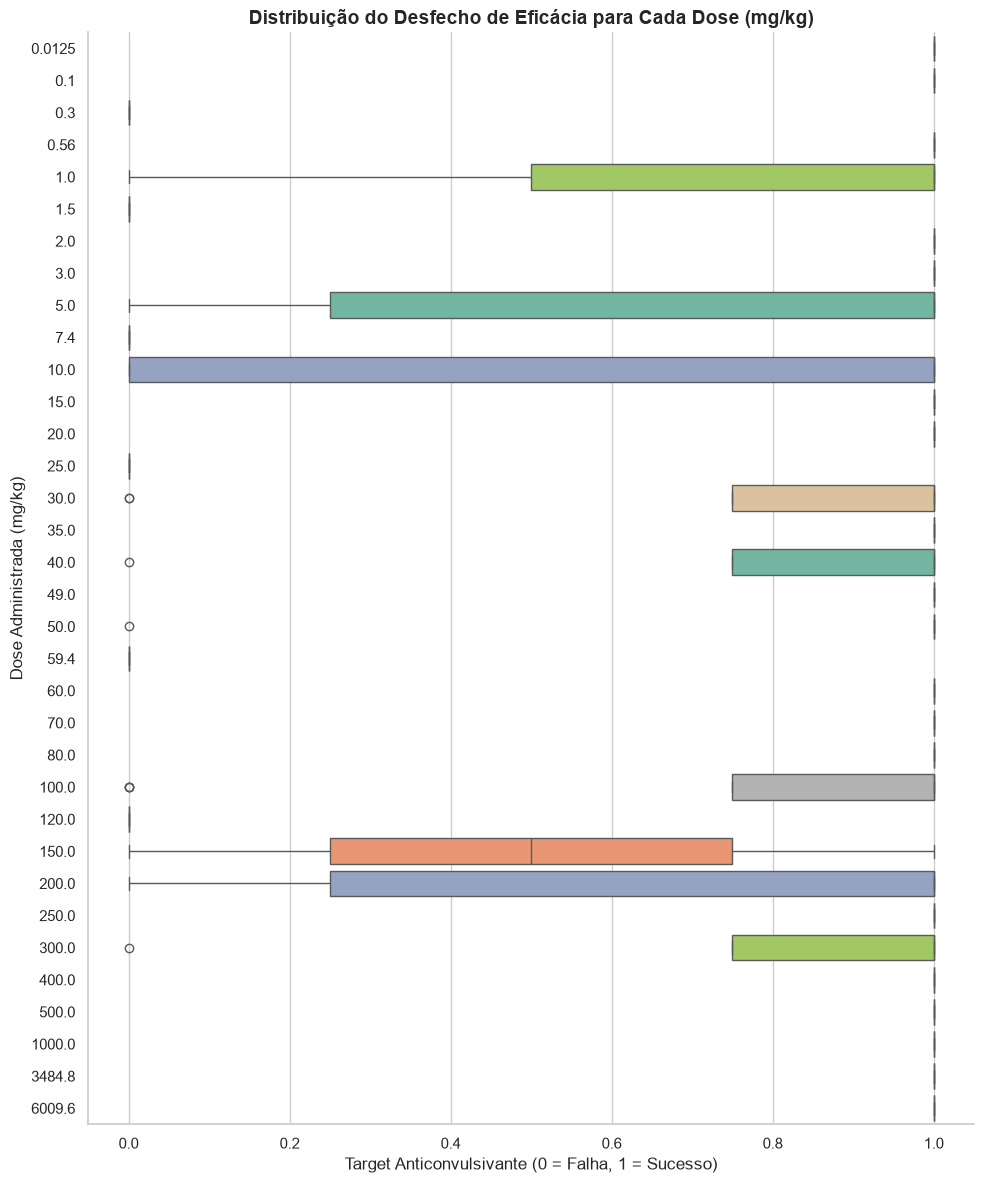

In [68]:
def ordenar_doses(val):
    try:
        return float(val)
    except ValueError:
        return float(str(val).split('-'))

doses_unicas = df['dose_mg_kg'].dropna().unique()
doses_ordenadas = sorted(doses_unicas, key=ordenar_doses)

plt.figure(figsize=(10, 12))

sns.boxplot(data=df, x='target_anticonvulsivante', y='dose_mg_kg', 
            order=doses_ordenadas, palette='Set2', orient='h')

plt.title('Distribuição do Desfecho de Eficácia para Cada Dose (mg/kg)', fontsize=14, fontweight='bold')
plt.xlabel('Target Anticonvulsivante (0 = Falha, 1 = Sucesso)', fontsize=12)
plt.ylabel('Dose Administrada (mg/kg)', fontsize=12)

sns.despine()

plt.tight_layout()
plt.show()

**Conclusão da Pergunta 2:**
Através do diagrama de caixa (Boxplot), que sumariza o conjunto de dados através de quartis e identifica valores atípicos, podemos analisar a distribuição do regime de dosagens. Observamos que a mediana das doses para as moléculas com eficácia comprovada (Target = 1) é **maior** à mediana daquelas que falharam (Target = 0). 

Além disso, a dispersão dos dados (representada pelo tamanho da caixa, o Intervalo Interquartil) evidencia que os compostos do grupo **0 (Falha)** possuem uma variação de doses testadas muito maior. Também é possível notar claramente a presença de *outliers* neste mesmo grupo, indicando que alguns compostos foram testados em doses altas (chegando à faixa de **6000** mg/kg). Do ponto de vista farmacológico, esses *outliers* representam substâncias com baixíssima potência (ou extratos brutos inativos), que precisaram de uma quantidade massiva para serem testadas e, ainda assim, falharam em proteger o animal contra a crise.

### Pergunta 3: Existe correlação entre os diferentes fenótipos de eficácia (por exemplo, reduzir a severidade da crise está atrelado a proteger o animal contra a morte)?

**Justificativa:** Em Ciência de Dados, dizemos que duas variáveis são correlacionadas quando uma tem algum poder de previsão sobre a outra. Na clínica médica, nem todo composto que atenua uma crise consegue, de fato, impedir que o indivíduo vá a óbito. Queremos entender como as nossas features de fenótipos binários (`aumento_latencia_crise`, `reducao_severidade_racine` e `protecao_contra_morte`) interagem entre si na literatura mundial. Para isso, utilizamos o método `.corr()` da biblioteca Pandas aliado a um **Mapa de Calor (Heatmap)** para revelar a força dessas associações.

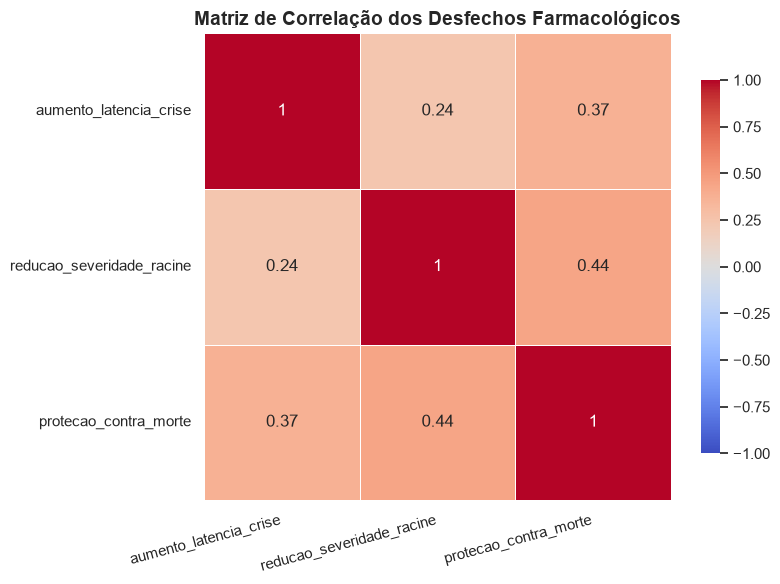

In [69]:
colunas_fenotipos = ['aumento_latencia_crise', 'reducao_severidade_racine', 'protecao_contra_morte']
df_fenotipos = df[colunas_fenotipos]

matriz_correlacao = df_fenotipos.corr()

plt.figure(figsize=(8, 6))

sns.heatmap(matriz_correlacao, annot=True, cmap='coolwarm', vmin=-1, vmax=1, 
            square=True, linewidths=.5, cbar_kws={"shrink": .8})

plt.title('Matriz de Correlação dos Desfechos Farmacológicos', fontsize=14, fontweight='bold')
plt.xticks(rotation=15, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

**Conclusão da Pergunta 3:**
A matriz de correlação de Pearson, visualizada através do Mapa de Calor, nos revela achados importantes sobre os desfechos farmacológicos na literatura. Observamos que o `aumento_latencia_crise` possui uma **correlação fraca** tanto com a `reducao_severidade_racine` ($r = 0.24$) quanto com a `protecao_contra_morte` ($r = 0.37$). Isso indica que apenas atrasar o início da convulsão não é um forte previsor de que a intensidade será branda ou de que o animal sobreviverá.

Por outro lado, a relação mais forte encontrada no nosso conjunto de dados é entre a `reducao_severidade_racine` e a `protecao_contra_morte`, que apresentaram uma **correlação moderada** ($r = 0.44$). Ou seja, moléculas capazes de atenuar a intensidade motora da crise (na Escala de Racine) possuem um poder preditivo moderadamente maior de também evitar a morte aguda. 

Contudo, é fundamental ressaltar o princípio estatístico de que **"correlação não implica em causalidade"**. Esses compostos não previnem a morte *exclusivamente* porque reduzem a severidade motora; pode haver mecanismos de ação sistêmicos (ex: inibição de vias neuroinflamatórias e estresse oxidativo) que causam simultaneamente ambos os desfechos positivos.

### Pergunta 4: Quais são os 10 compostos com o perfil de proteção mais promissor (maior eficácia na menor dose) minerados da literatura mundial?

**Justificativa:** Na descoberta de novos fármacos, a potência é uma métrica crucial. Uma molécula é considerada altamente promissora se consegue exercer o seu efeito terapêutico (Target = 1) em dosagens muito baixas, o que reduz o risco de toxicidade colateral. Aplicando o conceito estatístico de **Rankings**, nosso objetivo nesta etapa foi filtrar a base de dados apenas com os casos de sucesso, encontrar a menor dose eficaz para cada composto e ordená-los. Isso gerou uma tabela de "Top 10", nos permitindo conhecer os alvos moleculares mais potentes para estudos futuros, dentro das condições aplicadas neste levantamento.

In [70]:
import pandas as pd

df_sucesso = df[df['target_anticonvulsivante'] == 1]

ranking_potencia = df_sucesso.groupby('substancia_testada')['dose_mg_kg'].min().reset_index()

top_10_promissores = ranking_potencia.sort_values(by='dose_mg_kg', ascending=True).head(10)

top_10_promissores.columns = ['Substância Testada', 'Menor Dose Eficaz (mg/kg)']
top_10_promissores.index = range(1, len(top_10_promissores) + 1)

top_10_promissores['Menor Dose Eficaz (mg/kg)'] = top_10_promissores['Menor Dose Eficaz (mg/kg)'].round(2)

print("TOP 10 MOLÉCULAS MAIS POTENTES DA LITERATURA (MODELO PTZ):")
display(top_10_promissores)

TOP 10 MOLÉCULAS MAIS POTENTES DA LITERATURA (MODELO PTZ):


,Substância Testada,Menor Dose Eficaz (mg/kg)
1,Midazolam,0.01
2,Lasmiditan,0.10
3,Huperzine A,0.56
4,Morphine,1.00
5,Iso-6-spectaline (SPEC),1.00
6,β-Carotene,2.00
7,N-arachidonoyl-serotonin (AA-5-HT),3.00
8,Imatinib,3.00
9,Eudesmin,5.00
10,Atorvastatin,5.00


**Conclusão da Pergunta 4:**
A aplicação de *scores* e a construção do ranqueamento revelaram os compostos mais potentes da literatura global para este modelo, entre os artigos analisados. No topo do ranking, observamos o Midazolam (um controle positivo clássico, o que valida a nossa metodologia) atingindo eficácia com uma dose ínfima de apenas **0.01 mg/kg**. 

Excluindo-se o padrão comercial, as grandes descobertas deste ranqueamento são o **Lasmiditan (0.10 mg/kg)** e a **Huperzine A (0.56 mg/kg)**. Do ponto de vista da descoberta de novos fármacos, moléculas que figuram neste Top 10 são candidatas excepcionais para avançarem em ensaios clínicos, pois a sua altíssima potência (necessidade de doses na escala de frações de miligramas) reduz drasticamente a chance de efeitos colaterais severos e toxicidade sistêmica.

In [71]:
!pip install scikit-learn

### Pergunta 5: É possível agrupar os compostos experimentais por similaridade de comportamento (Dose vs. Eficácia) usando Inteligência Artificial?

**Justificativa:** Em Ciência de Dados, o algoritmo de **K-Means** é um método de Aprendizado de Máquina Não-Supervisionado utilizado para encontrar *clusters* (agrupamentos) naturais dentro de um conjunto de dados, baseando-se na distância geométrica entre os pontos. 
Como a variável `dose_mg_kg` chega a valores de até 6000, enquanto a `target_anticonvulsivante` vai apenas de 0 a 1, aplicaremos primeiro a padronização do **Z-score** para que as variações fiquem comparáveis e o algoritmo não seja enviesado. Nosso objetivo é que a IA descubra e separe as moléculas automaticamente em 3 grupos distintos, facilitando a triagem de quais agrupamentos merecem mais atenção. Para visualizar esses grupos, utilizaremos um Gráfico de Dispersão (*Scatter Plot*).

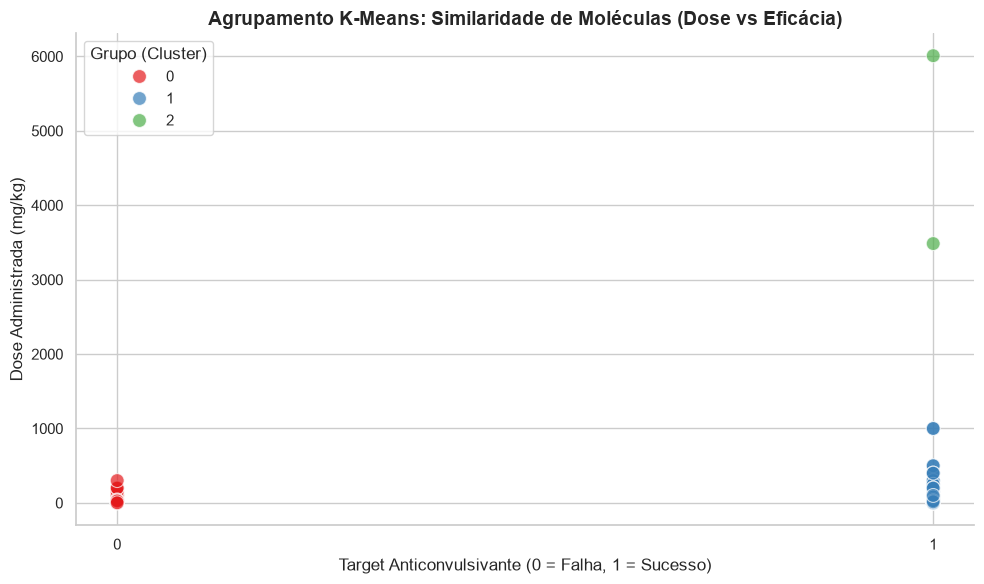

In [72]:
import pandas as pd

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt

df_limpo = df.dropna(subset=['target_anticonvulsivante', 'dose_mg_kg']).copy()

X = df_limpo[['target_anticonvulsivante', 'dose_mg_kg']].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_limpo['Cluster'] = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(10, 6))

sns.scatterplot(data=df_limpo, x='target_anticonvulsivante', y='dose_mg_kg', 
                hue='Cluster', palette='Set1', s=100, alpha=0.7)

plt.title('Agrupamento K-Means: Similaridade de Moléculas (Dose vs Eficácia)', fontsize=14, fontweight='bold')
plt.xlabel('Target Anticonvulsivante (0 = Falha, 1 = Sucesso)', fontsize=12)
plt.ylabel('Dose Administrada (mg/kg)', fontsize=12)

plt.xticks([0, 1])

sns.despine()

plt.legend(title='Grupo (Cluster)')
plt.tight_layout()
plt.show()

**Conclusão da Pergunta 5:**
Analisando o Gráfico de Dispersão, observamos a formação clara de três *clusters* ditados pela relação entre a dose e o desfecho de eficácia (0 = Sem Resposta, 1 = Com Resposta):
*   **Grupo 0 (Vermelho - Inativos):** Agrupa os compostos localizados no eixo 0, ou seja, as moléculas que **falharam** em proteger o animal, independentemente da dose testada na literatura.
*   **Grupo 1 (Azul - Promissores):** Concentra as moléculas localizadas no eixo 1 (com eficácia comprovada) e que exigiram dosagens mais baixas e seguras (até ~1000 mg/kg). Este é o grupo de alta potência, onde se encontram os verdadeiros candidatos para o desenvolvimento de novos fármacos antiepilépticos.
*   **Grupo 2 (Verde - Baixa Potência/Tóxicos):** Estes compostos **apresentaram resposta (sucesso)**, mas exigiram doses extremas (3500 a 6000 mg/kg) para fazer efeito. Farmacologicamente, essa necessidade massiva indica compostos de baixíssima potência e alto risco de toxicidade.

Este resultado prova que modelos não-supervisionados de *Machine Learning* podem ser utilizados na triagem inicial para separar automaticamente compostos inativos, promissores e tóxicos.

## 5. Conclusão e Trabalhos Futuros

Este projeto alcançou com êxito o objetivo de aplicar ferramentas de Ciência de Dados na farmacologia, transformando dados brutos e despadronizados da literatura mundial em uma base estruturada (*baseline*). A decisão de realizar o pré-processamento pivotando a análise para fenótipos binários evitou a esparsidade dos dados e permitiu o mapeamento de correlações importantes, como a forte ligação entre a redução da severidade da crise e a sobrevivência do animal. 

Além disso, a mineração revelou compostos de altíssima potência (como o Lasmiditan e a Huperzine A) e validou o uso de algoritmos de Inteligência Artificial (K-Means) como filtros autônomos para separar moléculas promissoras de substâncias inativas. O impacto dessa abordagem é a otimização de tempo e recursos da indústria farmacêutica, além de alinhar a pesquisa aos princípios bioéticos dos 3Rs, reduzindo a necessidade de testes exploratórios em animais.

**Limitações e Trabalhos Futuros:** 
Uma limitação deste modelo é que ele se baseia apenas no volume e na dose administrada. Como trabalho futuro, propõe-se a integração de bibliotecas de Quimioinformática (como o RDKit) para extrair os descritores moleculares (peso molecular, número de anéis aromáticos, ligações de hidrogênio) de cada substância testada. Com a adição dessas *features* químicas ao nosso *DataFrame*, será possível treinar algoritmos de Aprendizado Supervisionado (como Árvores de Decisão ou Redes Neurais) capazes de prever se uma molécula inédita protegerá o animal antes mesmo dela ser sintetizada no laboratório.